# 2. Vector Damage Assessment

This notebook demonstrates flood damage assessment using vector exposure data (polygons) with a raster hazard map.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from damagescanner import DamageScanner

## Define input data

- **Hazard**: Flood inundation map (GeoTIFF)
- **Exposure**: Land use polygons (GeoPackage)
- **Vulnerability**: Depth-damage curves and maximum damage values

In [2]:
data_path = Path("..") / "data" / "kampen"

hazard = data_path / "hazard" / "1in100_inundation_map.tif"
exposure = data_path / "exposure" / "landuse.gpkg"
curves = data_path / "vulnerability" / "curves_landuse.csv"
maxdam = data_path / "vulnerability" / "maxdam_landuse.csv"

## Initialize DamageScanner

The scanner detects vector exposure data and uses the vector-based assessment approach.

In [3]:
ds = DamageScanner(
    hazard_data=hazard,
    feature_data=exposure,
    curves=curves,
    maxdam=maxdam,
)

print(f"Assessment type: {ds.assessment_type}")

Assessment type: vector


## Calculate damages

The `object_col` parameter specifies which column contains the land use classification.

In [4]:
result = ds.calculate(object_col="landuse")

print(f"Features assessed: {len(result)}")
print(f"Total damage: €{result['damage'].sum():,.0f}")
result.head()

Calculating damage: 100%|████████████████████████████████████████████████████████| 6615/6615 [00:01<00:00, 5628.07it/s]

Features assessed: 6615
Total damage: €1,165,487,934


,osm_id,landuse,geometry,coverage,values,maximum_damage,damage
0,1300409,grass,"MULTIPOLYGON (((197915.809 504006.57, 197914.4...","[0.2587259113788605, 0.19168396294116974, 0.29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5,0.000000
1,1300411,forest,"MULTIPOLYGON (((196975.524 504827.199, 196994....","[0.008669080212712288, 0.0376882366836071, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,0.000000
2,1300414,grass,"MULTIPOLYGON (((195550.949 504973.323, 195501....","[0.2384762465953827, 0.8920947909355164, 0.841...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...",5,15813.600526
3,1300415,grass,"MULTIPOLYGON (((197929.547 505068.356, 197897....","[0.023570779711008072, 0.6478395462036133, 0.8...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",5,33847.291082
4,1300418,grass,"MULTIPOLYGON (((198303.698 504350.452, 198303....","[0.0537559874355793, 0.17182405292987823, 0.24...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",5,33871.937415


In [7]:
result

,osm_id,landuse,geometry,coverage,values,maximum_damage,damage
0,1300409,grass,"MULTIPOLYGON (((197915.809 504006.57, 197914.4...","[0.2587259113788605, 0.19168396294116974, 0.29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",5,0.000000
1,1300411,forest,"MULTIPOLYGON (((196975.524 504827.199, 196994....","[0.008669080212712288, 0.0376882366836071, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10,0.000000
2,1300414,grass,"MULTIPOLYGON (((195550.949 504973.323, 195501....","[0.2384762465953827, 0.8920947909355164, 0.841...","[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, ...",5,15813.600526
3,1300415,grass,"MULTIPOLYGON (((197929.547 505068.356, 197897....","[0.023570779711008072, 0.6478395462036133, 0.8...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",5,33847.291082
4,1300418,grass,"MULTIPOLYGON (((198303.698 504350.452, 198303....","[0.0537559874355793, 0.17182405292987823, 0.24...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",5,33871.937415
...,...,...,...,...,...,...,...
6610,NaN,forest,"MULTIPOLYGON (((192290.237 509875.704, 192381....","[0.03463207557797432, 0.2713286578655243, 0.54...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...",10,6055.089532
6611,NaN,forest,"MULTIPOLYGON (((192262.734 509954.211, 192263....","[0.4400310814380646, 0.7280258536338806, 0.563...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...",10,4824.209744
6612,NaN,grass,"MULTIPOLYGON (((192349.587 509994.296, 192385....","[0.021031826734542847, 0.07979804277420044, 0....","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",5,48555.671036
6613,NaN,farmland,"MULTIPOLYGON (((192511.185 510402.681, 192652....","[0.12178021669387817, 0.5802333950996399, 0.49...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, ...",10,881398.761948


## Summarize by land use type

In [5]:
damage_by_landuse = (
    result.groupby("landuse")["damage"].sum().sort_values(ascending=False)
)
damage_by_landuse

landuse
industrial        4.081304e+08
residential       3.385922e+08
grass             2.336089e+08
farmland          1.549833e+08
forest            1.097205e+07
orchard           1.090361e+07
retail            3.353789e+06
meadow            1.595567e+06
construction      1.435103e+06
allotments        1.260118e+06
cemetery          3.938228e+05
farmyard          2.161636e+05
reservoir         2.377325e+04
static_caravan    1.900498e+04
commercial        0.000000e+00
scrub             0.000000e+00
Name: damage, dtype: float64

## Visualize results

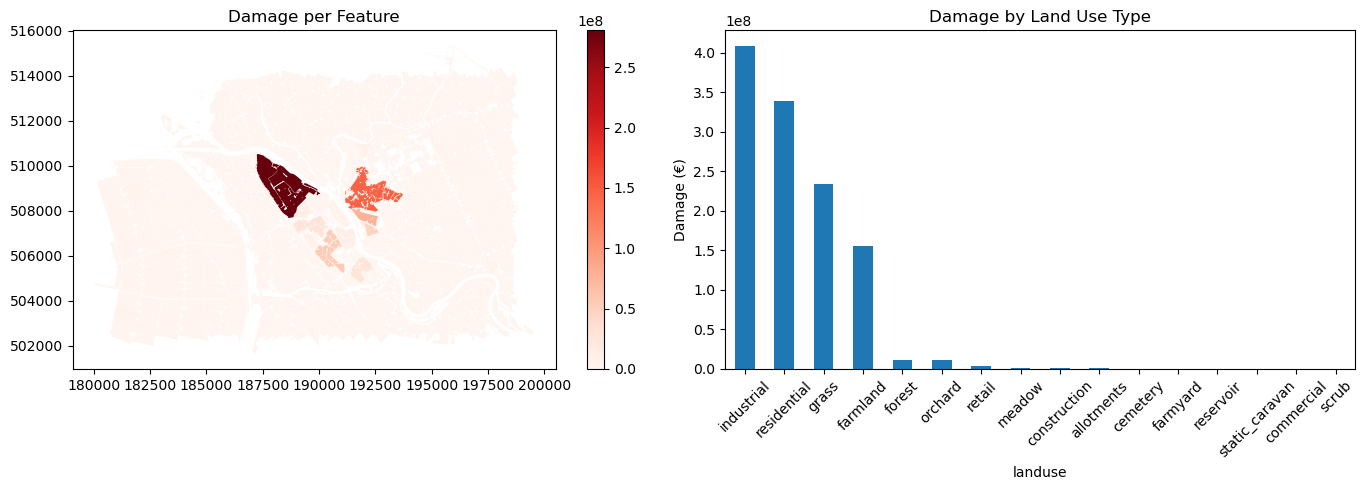

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Map of damages
result.plot(column="damage", cmap="Reds", legend=True, ax=axes[0])
axes[0].set_title("Damage per Feature")

# Bar chart
damage_by_landuse.plot.bar(ax=axes[1])
axes[1].set_title("Damage by Land Use Type")
axes[1].set_ylabel("Damage (€)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()